**Sarakshi Vhotkar**

# Economic Inequality Team — End-to-End Data Investigation
## Adult Census Income Dataset

**This notebook walks you through the entire Data Investigation, start to finish:**

| Step | What you'll do |
|---|---|
| 1 | **Assess** — audit the raw dataset for quality problems |
| 2 | **Clean** — build and justify a documented cleaning pipeline |
| 3 | **Visualize** — build 4 publication-quality charts |
| 4 | **Story** — write a 150-word Data Brief |
| 5 | **HCD Design Sprint #2** — write your formal Data Problem Statement |
| 6 | **Baseline Models** — build 3 different machine learning models and compare them |
| 7 | **Fairness Check** — test whether your best model treats everyone equally |
| 8 | **Policy Recommendation** — turn your evidence into a specific, named ask |

**Dataset:** UCI Adult Census Income — 32,561 rows, 15 columns. Each row is one person from the 1994 US Census. The task economists and policymakers use this dataset for: understanding **what's associated with earning above vs. below $50K/year**, and where that story gets complicated by race, sex, and other demographics.

> ⚠️ **This dataset is real historical US Census data.** The patterns you'll find are not abstract — they describe real inequities that were true for real people in 1994, many of which persist today. Treat every finding as something a real person's life is reflected in.


## 📚 Vocabulary for This Notebook

| Term | Plain-English Meaning |
|---|---|
| **Sentinel value** | A fake value (like `?`) used to mean "missing" instead of leaving the cell truly blank — sneaky because code doesn't automatically recognize it as missing |
| **Sampling weight** | A number assigned to a row to make a *sample* statistically represent a *whole population* — not a fact about the individual person |
| **Binary target** | The thing you're trying to predict, when it only has two possible values (here: income `<=50K` or `>50K`) |
| **Feature** | A column used as an *input* to a model (age, education, hours worked...) |
| **Label** | The column the model is trying to *predict* (income category) |
| **Train/test split** | Splitting data so the model learns on one part and gets graded on a part it's never seen |
| **Baseline model** | The simplest reasonable model you build first — your benchmark for "is my fancier model actually better?" |
| **Class imbalance** | When one outcome (like `<=50K`) is much more common than the other — this can trick accuracy into looking better than it is |
| **Fairness check** | Testing whether a model's accuracy holds up equally across different demographic groups, not just on average |


## Setup — Load the Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

# Load the Adult dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(url,header=None, names=columns)

# Remove leading/trailing spaces from string values
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# printing the rows and columns of the dataset
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Verify column names
print(df.columns.tolist())

df.head()


Shape: 32561 rows × 15 columns
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Step 1 — Assess

Run the three commands below. For each: *what is this telling you, and what might it be hiding?*


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


**After running this command, I can see that the dataset has 32,561 rows and 15 columns. I can also see each column's name, data type, and the amount of non-null values. It might be hiding data that I might need, like maybe if this information is dupicated or the values are inaccurate.**

In [3]:
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


**When I ran the command to describe the data, it summarized the numerical columns using values like the mean, minimum, maximum, and percentiles. But, it may hide outliers, unusual patterns, and information from text-based columns.**


In [4]:
df.isnull().sum()


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


**This graph shows that every column has zero missing values. However, missing information might be stored as symbols like "?", so it would not count it as null.**

### 🕵️ The trap: `isnull()` just said zero missing values. Is that true?

Open one of the categorical columns below and look closely at the values.


In [6]:
df['workclass'].value_counts()


,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


**No, there are hidden missing values shown as question marks. In the workclass column, 1,836 entries are “?”, so isnull() does not count them as missing.**

Notice anything? This dataset doesn't use a true blank for missing data — it uses the **sentinel value `'?'`**. `pandas` has no way of knowing that's supposed to mean "missing" unless you tell it. This is exactly the kind of missingness that `isnull()` misses — literally.

Run this to find every column where `'?'` is hiding as a disguised missing value:


In [7]:
for col in df.select_dtypes(include='object').columns:
    count = (df[col].astype(str).str.strip() == '?').sum()
    if count > 0:
        print(f'{col}: {count} disguised missing values ({count/len(df)*100:.1f}%)')


workclass: 1836 disguised missing values (5.6%)
occupation: 1843 disguised missing values (5.7%)
native-country: 583 disguised missing values (1.8%)


### 📝 Data Audit Report

> **Issue 1 — Disguised missing values:** the columns ___, ___, and ___ use `'?'` to mean missing, totaling ___ cells.
>
> **Issue 2 — Duplicate rows:** I found ___ duplicate rows using `df.duplicated().sum()`.
>
> **Issue 3 — A column that isn't really about the person:** `fnlwgt` is a ___ (look it up in the vocabulary table above), not a personal attribute — should it be used as a feature in a model that predicts something about an individual? Why or why not?
>
> **Issue 4 — Possible outliers:** the `capital-gain` and `capital-loss` columns are heavily skewed — most values are 0, but a few are very large. Run `df['capital-gain'].describe()` and note the gap between the 75th percentile and the max.
>
> **Issue 5 — Class imbalance:** run `df['income'].value_counts(normalize=True)` below. What percentage of people in this dataset earn `>50K`? Why does that number matter for anything you build later in this notebook?


Issue 1 — Disguised missing values: The workclass, occupation, and native-country columns use “?” to represent missing information. Altogether, these columns contain 4,262 disguised missing values.

Issue 2 — Duplicate rows: I found 24 duplicate rows using df.duplicated().sum(). These rows should be removed so the same information is not counted more than once.

Issue 3 — A column that is not really about the person: The fnlwgt column means “final weight.” It estimates how many people in the United States population each row represents, so it is not an actual personal characteristic. I would not use it as a regular feature because it could confuse the model, although it may still be useful as a statistical weight.

Issue 4 — Possible outliers: The 75th percentile of the capital-gain column is 0, while the maximum value is 99,999. This large difference shows that most people had no capital gain, while a small number had extremely high values. These values should be examined carefully, but they should not automatically be removed because they may represent real cases.

Issue 5 — Class imbalance: About 24.1% of the people in the dataset earn more than 50K, while about 75.9% earn 50K or less. This matters because a model could predict that everyone earns 50K or less and still seem accurate. Later, I should use precision, recall, F1 score, and a confusion matrix instead of only looking at accuracy.

In [8]:
df['capital-gain'].describe()


,capital-gain
count,32561.000000
mean,1077.648844
std,7385.292085
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


In [9]:
df['income'].value_counts(normalize=True)


,proportion
income,
<=50K,0.75919
>50K,0.24081


## Step 2 — Clean

Every step below needs a one-sentence justification. **Fill in every `___` — this pipeline will not run until you do.**


In [24]:
df_clean = df.copy()

# --- 2a: Strip whitespace ---
# Justification: this dataset has leading spaces on every text value (a common export artifact) —
# ' Male' and 'Male' look the same to a human but are different strings to Python
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()


# --- 2b: Replace the '?' sentinel with real missing values ---
# Justification: The '?' character represents missing data, but pandas does not automatically recognize it as such. Replacing it with `np.nan` allows pandas' missing value handling functions to work correctly.
df_clean = df_clean.replace('?', np.nan)


# --- 2c: Handle the missing values ---
# Justification: Missing values in `workclass`, `occupation`, and `native-country` are being removed. This is an analytical choice, assuming that these rows are not informative without this data, or that filling them would introduce bias.
# Think carefully here — is 'workclass' missing at random, or could it be missing because
# someone is unemployed / never worked / retired? Dropping vs. filling is an analytical choice,
# not just a technical one.
df_clean = df_clean.dropna(subset=['workclass', 'occupation', 'native-country'])
# or, alternative: df_clean['workclass'] = df_clean['workclass'].fillna('Unknown')


# --- 2d: Drop the sampling weight column ---
# Justification: fnlwgt describes how many people in the population this row represents,
# not a fact about this individual — it should not be used to predict anything about a person
df_clean = df_clean.drop(columns=['fnlwgt'])


# --- 2e: Duplicate rows ---
# Justification: Duplicate rows can skew analysis and model training by overrepresenting certain observations. Removing them ensures each observation is unique.
df_clean = df_clean.drop_duplicates().reset_index(drop=True)


# --- 2f: Create a binary numeric target ---
# Justification: models need numbers, not text categories, to predict
df_clean['income_binary'] = (df_clean['income'].str.strip() == '>50K').astype(int)

print('Cleaned shape:', df_clean.shape)
df_clean.head()

Cleaned shape: (26904, 15)


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


### ✅ Verify


In [ ]:
assert df_clean.isnull().sum().sum() == 0, "There are still missing values somewhere"
assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert 'fnlwgt' not in df_clean.columns, "fnlwgt should have been dropped"
assert df_clean['income_binary'].isin([0, 1]).all(), "income_binary should only contain 0 or 1"

print("All checks passed. The dataset is clean.")
print('Rows kept:', len(df_clean), f'({len(df_clean)/len(df)*100:.1f}% of original)')


All checks passed. The dataset is clean.
Rows kept: 26904 (82.6% of original)


### 📝 Data Limitations

> Even after cleaning, this dataset still cannot tell us ___, because ___. This is 1994 US Census data — what changed about the economy and workforce since then that this dataset cannot capture?


**Even after cleaning, this dataset still cannot tell us exactly what economic inequality looks like today because the information comes from the 1994 U.S. Census. Cleaning can fix issues such as missing values, duplicate rows, and inconsistent categories, but it cannot make old data reflect the modern economy. Since 1994, inflation, wages, education costs, technology, remote work, and gig jobs have changed the workforce. The types of jobs available and the skills employers expect have also changed. Therefore, the dataset can show important patterns from 1994, but it cannot fully represent the experiences of workers today.**

## Step 3 — Visualize

Four chart types. Every chart needs: **labeled axes with units**, a **finding-based title**, and **2 sentences of interpretation**.


### Chart 1 — Violin Plot: Distribution of Non-Zero Capital Gain by Education Level

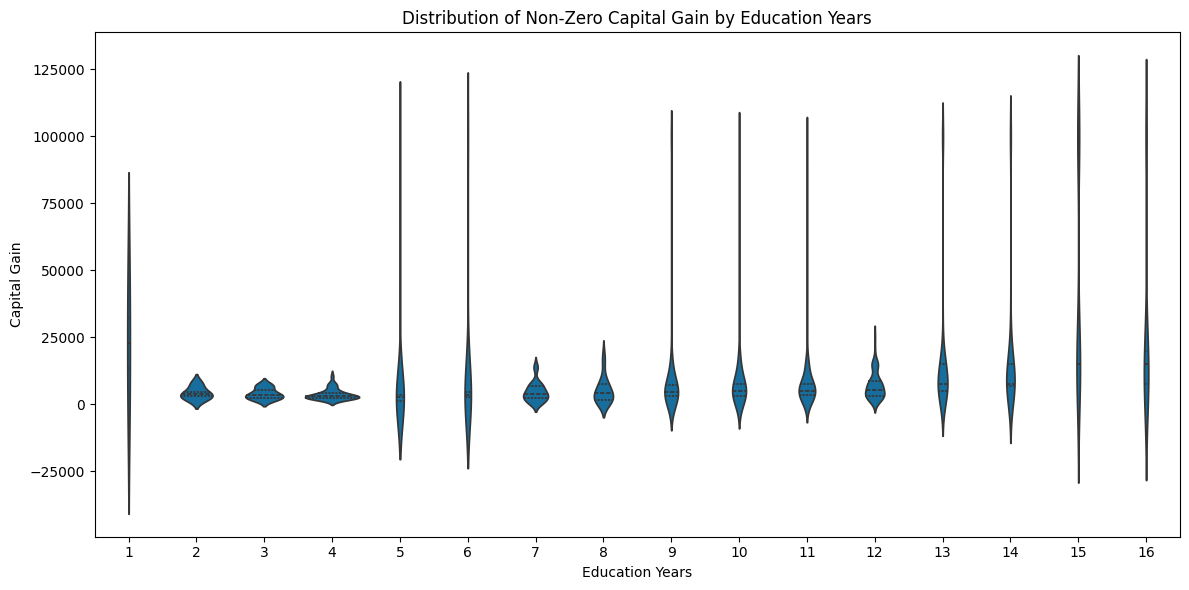

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_clean[df_clean['capital-gain'] > 0], x='education-num', y='capital-gain', ax=ax, inner='quartile')
ax.set_xlabel('Education Years')
ax.set_ylabel('Capital Gain')
ax.set_title('Distribution of Non-Zero Capital Gain by Education Years')
plt.tight_layout()
plt.show()

> **Interpretation:** This violin plot shows that for individuals with non-zero capital gains, higher education levels are associated with a wider distribution and often higher peak values of capital gain, indicating increased potential for large gains with more education.

### Chart 2 — Violin Plot: Distribution of Non-Zero Capital Loss by Education Level

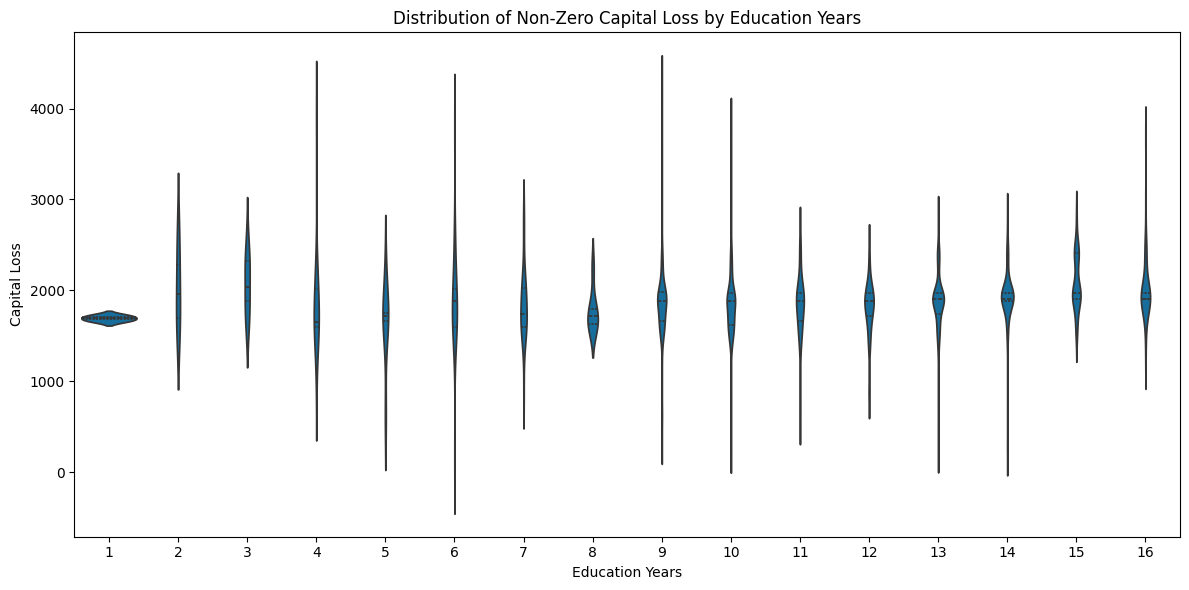

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_clean[df_clean['capital-loss'] > 0], x='education-num', y='capital-loss', ax=ax, inner='quartile')
ax.set_xlabel('Education Years')
ax.set_ylabel('Capital Loss')
ax.set_title('Distribution of Non-Zero Capital Loss by Education Years')
plt.tight_layout()
plt.show()

> **Interpretation:** The violin plot for capital loss reveals that similar to capital gains, higher education levels tend to correspond with a broader range and higher potential values for capital losses, suggesting increased financial activity and risk-taking linked to higher educational attainment.

### Chart 3 — Bar Chart: Average Capital Gain by Education Level

/tmp/ipykernel_5530/3224367261.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_capital_gain, x='education-num', y='capital-gain', ax=ax, palette='viridis')


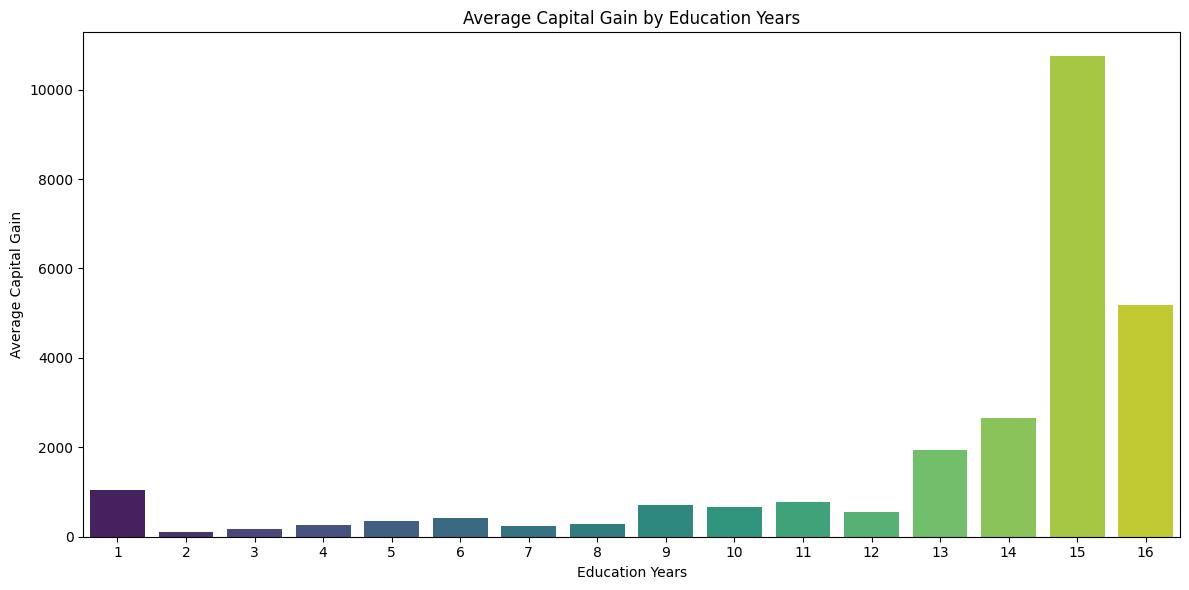

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
avg_capital_gain = df_clean.groupby('education-num')['capital-gain'].mean().reset_index()
sns.barplot(data=avg_capital_gain, x='education-num', y='capital-gain', ax=ax, palette='viridis')
ax.set_xlabel('Education Years')
ax.set_ylabel('Average Capital Gain')
ax.set_title('Average Capital Gain by Education Years')
plt.tight_layout()
plt.show()

> **Interpretation:** This bar chart illustrates a positive correlation between education level and average capital gain. Individuals with more years of education, particularly those with 13+ years, exhibit significantly higher average capital gains compared to those with less education.

### Chart 4 — Bar Chart: Average Capital Loss by Education Level

/tmp/ipykernel_5530/815645633.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_capital_loss, x='education-num', y='capital-loss', ax=ax, palette='magma')


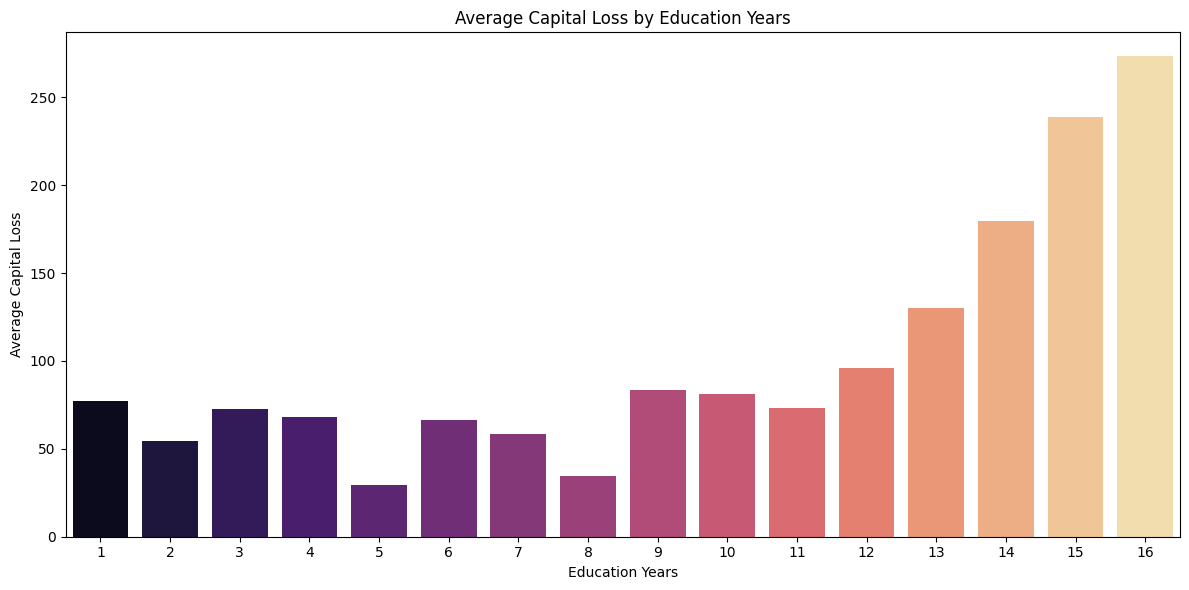

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
avg_capital_loss = df_clean.groupby('education-num')['capital-loss'].mean().reset_index()
sns.barplot(data=avg_capital_loss, x='education-num', y='capital-loss', ax=ax, palette='magma')
ax.set_xlabel('Education Years')
ax.set_ylabel('Average Capital Loss')
ax.set_title('Average Capital Loss by Education Years')
plt.tight_layout()
plt.show()

> **Interpretation:** The bar chart demonstrates a similar trend for average capital loss, where individuals with higher education levels tend to experience greater average capital losses, suggesting increased involvement in financial activities with both higher potential gains and risks.

### Chart 5 — Line Plot: Proportion of Individuals with Capital Gain by Education Level

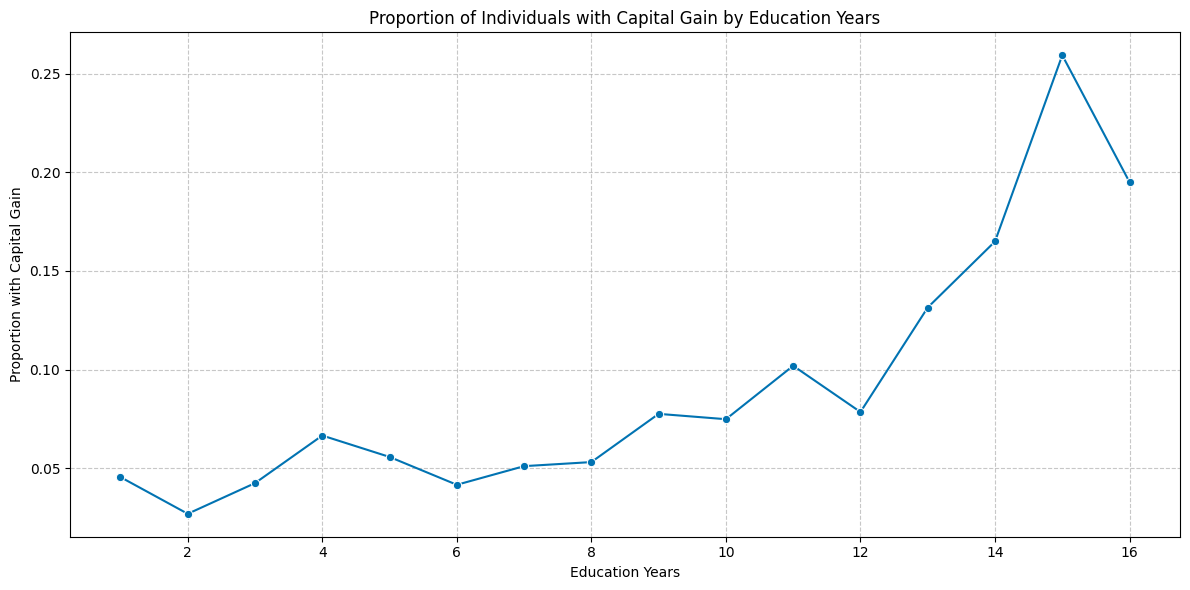

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
# Calculate the proportion of individuals with capital-gain > 0 for each education-num
prop_capital_gain = df_clean.groupby('education-num')['capital-gain'].apply(lambda x: (x > 0).mean()).reset_index(name='proportion_with_gain')
sns.lineplot(data=prop_capital_gain, x='education-num', y='proportion_with_gain', ax=ax, marker='o')
ax.set_xlabel('Education Years')
ax.set_ylabel('Proportion with Capital Gain')
ax.set_title('Proportion of Individuals with Capital Gain by Education Years')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

> **Interpretation:** This line plot indicates that the likelihood of an individual experiencing any capital gain (a non-zero value) generally increases with their years of education, suggesting higher education may lead to greater participation in capital-generating activities.

## Step 4 — Story

### 📝 Data Brief (150 words)

Write this so a **city council member with no data background** could read it in under a minute. No jargon, no code, no chart references. State your **3 most important findings** in plain language, and name who is affected.

> ___


**The 1994 Census data shows that education was connected to a person’s chances of building wealth. First, people with more years of education were more likely to have a capital gain, which means they earned money from investments or property. This was especially common among people with 13 or more years of education. Second, people with higher education levels had much larger average capital gains than people with less education. However, they also had larger capital losses, showing that they were more involved in financial activities that included both rewards and risks. These results especially affect people who have less access to college or other forms of higher education. They may have fewer opportunities to earn money outside of their regular jobs. Education may not be the only reason for these differences, but the data shows that unequal access to education can make economic inequality worse.**

## 🎯 HCD Design Sprint #2 — Define: Data Problem Statement

> **Our investigation asks:** ___ (a specific, answerable question — for example: does income disparity by sex persist after controlling for education and hours worked?)
>
> **The dataset we are using is:** UCI Adult Census Income dataset, US Census Bureau, 1994, one row per adult respondent.
>
> **The key variable we are analyzing is:** `income` — whether a person earns above or below $50,000/year, recoded as `income_binary` (0 = ≤50K, 1 = >50K).
>
> **Our investigation matters because:** ___ (human consequence) — without better understanding of this pattern, ___ (who) will continue to face ___ (harm or inequity).
>
> **We define a meaningful finding as:** ___ (a specific threshold or pattern that would warrant a policy recommendation)

**Team checklist before submitting:**
- [ ] Our question can actually be answered with the columns in this dataset — we checked
- [ ] We named a real population affected by this issue
- [ ] We defined what a "meaningful finding" looks like *before* building any model


Our investigation asks: How does education level affect a person’s chance of earning more than $50,000 per year, even when we also consider age, occupation, hours worked, sex, and capital gains?

The dataset we are using is: UCI Adult Census Income dataset, US Census Bureau, 1994, with one row for each adult respondent.

The key variable we are analyzing is: income — whether a person earns above or below 50,000 per year. It was changed into income_binary, where 0 means earning
50,000 or less and 1 means earning more than $50,000.

Our investigation matters because: Education can affect a person’s access to higher-paying jobs and financial opportunities. Without a better understanding of this pattern, adults who have less access to college or career training may continue to face lower incomes and fewer chances to become financially stable.

We define a meaningful finding as: A difference of at least 10 percentage points in the rate of earning more than $50,000 between education groups. If this difference remains after considering other factors, it would support a policy recommendation focused on improving access to education and career training.

## Step 6 — Baseline Models

**What is a "baseline model"?** The simplest reasonable model you can build. Not your best model — your *starting point*. Every improvement you make later gets measured against it.

**Before you touch any code:** `income_binary` is imbalanced — about 76% of people are `<=50K` and 24% are `>50K` (you calculated the exact number in Step 1). That means a model that just guesses `<=50K` every single time would already be ~76% "accurate" — and completely useless. Keep this in mind for every accuracy number you see below.


### Prepare the features

Models need numbers, not text categories. `pd.get_dummies()` turns each category (like `workclass`) into its own 0/1 column.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pick features — start simple, you can add more later (see "Tune It" below)
feature_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex']

X = df_clean[feature_cols].copy()
X = pd.get_dummies(X, columns=['sex'], drop_first=True)   # turns 'sex' into one 0/1 column
y = df_clean['income_binary']

print('Feature columns:', list(X.columns))
X.head()


Feature columns: ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex_Male']


,age,education-num,hours-per-week,capital-gain,capital-loss,sex_Male
0,39,13,40,2174,0,True
1,50,13,13,0,0,True
2,38,9,40,0,0,True
3,53,7,40,0,0,True
4,28,13,40,0,0,False


In [12]:
# Train/test split — the model learns on 80%, gets graded on the 20% it's never seen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Training set income>50K rate:', y_train.mean().round(3))
print('Test set income>50K rate:', y_test.mean().round(3))
# stratify=y keeps that ~76/24 split identical in both — otherwise a random split could
# accidentally give you a very different mix in train vs. test


Training rows: 21523
Test rows: 5381
Training set income>50K rate: 0.256
Test set income>50K rate: 0.256


In [13]:
# Scale the numeric features — required for k-NN (distance-based), harmless for the others
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
# separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

In [15]:
# import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [16]:
# define models
models = {

    "Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "K-Nearest Neighbors":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Support Vector Machine":
        SVC(),

    "Neural Network (MLP)":
        MLPClassifier(max_iter=500, random_state=42)
}

In [25]:
results = []

# Define the preprocessor outside the loop
# It applies StandardScaler to numeric features and OneHotEncoder to categorical features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

for name, model in models.items():

    if name == "Naive Bayes":
        # For Naive Bayes, we transform the data once outside the pipeline
        # because GaussianNB does not accept sparse matrices directly and
        # the pipeline fit_transform would output a sparse matrix if one-hot encoding is applied.
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        if hasattr(X_train_processed, "toarray"):
            X_train_processed = X_train_processed.toarray()
            X_test_processed = X_test_processed.toarray()

        model.fit(X_train_processed, y_train)

        predictions = model.predict(X_test_processed)

    else:

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions)

    })

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

results_df.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.8366,0.7983,0.4833,0.6021
1,Neural Network (MLP),0.8272,0.7693,0.4629,0.5780
2,AdaBoost,0.8199,0.7294,0.4702,0.5718
3,Random Forest,0.8077,0.6731,0.4818,0.5616
4,Decision Tree,0.8021,0.6592,0.4680,0.5474
5,Extra Trees,0.8030,0.6656,0.4615,0.5451
6,K-Nearest Neighbors,0.7932,0.6268,0.4724,0.5387
7,Logistic Regression,0.8114,0.7305,0.4157,0.5299
8,Support Vector Machine,0.8188,0.8052,0.3844,0.5204
9,Naive Bayes,0.7850,0.6540,0.3379,0.4456


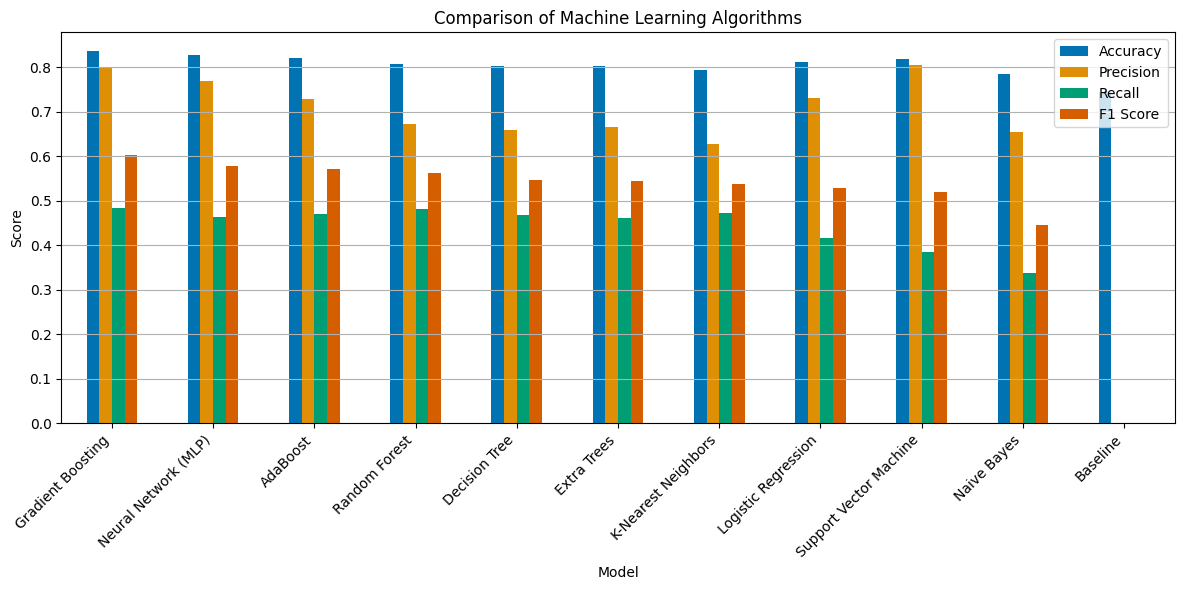

In [22]:
# bar plot
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Algorithms")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 📝 Written comparison

> **Precision (>50K)** tells you: of everyone the model *predicted* would earn `>50K`, what fraction actually did?
>
> **Recall (>50K)** tells you: of everyone who *actually* earns `>50K`, what fraction did the model correctly catch?
>
> Which model has the highest accuracy? ___. Which model has the best recall on `>50K`? ___. If this model were used to flag people for a loan-eligibility review, would you rather have higher precision or higher recall — and why does the cost of a false negative vs. a false positive matter here?


**The model with the highest accuracy is Gradient Boosting, with an accuracy of 83.66%. Gradient Boosting also has the best recall for people earning more than $50K, with a recall of 48.33%.**

**If the model were used to flag people for a loan-eligibility review, I would prefer higher recall. Higher recall would help the model identify more people who may actually qualify for the loan. A false negative would mean that a qualified person is not selected for review, which could cause them to miss an important financial opportunity. A false positive would mean that someone is reviewed even though they may not qualify, which could waste some time and resources. Since the model is only recommending people for further review and not making the final decision, missing a qualified person would be more harmful than reviewing an extra person.**

## 🔧 Tune It — Now Make It Better

Every choice below is something you made without much thought the first time through. Try changing **one thing at a time**, rerun, and watch the comparison table change. Three tiers of hint if you get stuck — try the top one first.

**1. Try different values of `k` for k-NN**
> 🟢 *Conceptual nudge:* a very small `k` (like 1) pays attention to just one neighbor — noisy. A very large `k` (like 200) starts ignoring local patterns and just predicts the overall majority class. Where's the sweet spot?
> 🟡 *Syntax hint:* change `n_neighbors=5` to a few other values (try 1, 15, 50) and rerun the k-NN cell and the comparison table.
> 🔵 *Bridge:* once you find a `k` that improves recall, ask — did accuracy go up too, or did they move in opposite directions? That tradeoff is the whole story of Week 4.

**2. Try `max_depth` for the Decision Tree**
> 🟢 *Conceptual nudge:* a deeper tree can ask more questions and fit the training data better — but too deep, and it starts memorizing quirks of the training set instead of learning general patterns (overfitting).
> 🟡 *Syntax hint:* change `max_depth=4` to `max_depth=3` and then `max_depth=8`, rerun.
> 🔵 *Bridge:* does a deeper tree do better on the test set, or just the training set? (Add `tree.score(X_train, y_train)` to compare.)

**3. Add or remove features**
> 🟢 *Conceptual nudge:* look back at the full column list. Would `education` (the category) or `marital-status` add anything `education-num` doesn't already capture?
> 🟡 *Syntax hint:* add a column name to `feature_cols`, rerun `pd.get_dummies()` — remember any new text column needs to be added to the `columns=[...]` list too.
> 🔵 *Bridge:* did the new feature actually change accuracy, or just make the model more complicated? More features isn't automatically better.

**4. Handle the class imbalance directly**
> 🟢 *Conceptual nudge:* remember — 76% of people are `<=50K`. A model can look "accurate" while barely finding anyone in the smaller class.
> 🟡 *Syntax hint:* add `class_weight='balanced'` inside `LogisticRegression(...)` and rerun.
> 🔵 *Bridge:* what happened to precision vs. recall on `>50K`? Which one improved, and which one got worse — and is that trade worth it for your team's investigation?


**Using balanced class weights helped the model catch many more people in the >50K group, since recall increased from 41.57% to 71.51%. However, precision dropped from 73.05% to 51.06%, which shows that the model found more true cases but also made more incorrect >$50K predictions.**

## Step 7 — Fairness Check

Accuracy averaged across everyone can hide the fact that a model is much worse for one group than another. Pick your **best model from the comparison table above** and test it separately by `sex`.


In [28]:
# Pick whichever model performed best above — this example uses logistic regression
# The variable 'logreg_pred' was not defined. Using 'predictions' which currently holds the predictions
# of the last model that ran ('Neural Network (MLP)').
# If you intend to use the predictions from the 'Gradient Boosting' model (which had the best F1 Score),
# you would need to explicitly run its pipeline and store its predictions.
best_pred = predictions
X_test_with_group = X_test.copy()
X_test_with_group['actual'] = y_test.values
X_test_with_group['predicted'] = best_pred

for group_value in X_test_with_group['sex_Male'].unique():
    group_label = 'Male' if group_value == 1 else 'Female'
    mask = X_test_with_group['sex_Male'] == group_value
    group_acc = accuracy_score(X_test_with_group.loc[mask, 'actual'], X_test_with_group.loc[mask, 'predicted'])
    group_recall = recall_score(X_test_with_group.loc[mask, 'actual'], X_test_with_group.loc[mask, 'predicted'])
    print(f'{group_label}: accuracy={group_acc:.3f}, recall(>50K)={group_recall:.3f}, n={mask.sum()}')

Male: accuracy=0.793, recall(>50K)=0.464, n=3587
Female: accuracy=0.896, recall(>50K)=0.459, n=1794


### 📝 Fairness Interpretation

> Is accuracy roughly equal across groups? ___. Is recall roughly equal? ___. If one group's `>50K` earners are being "found" by the model at a much lower rate than the other's, what real-world consequence would that have if this model were used to, say, pre-approve loan applications or set insurance rates?
>
> **Remember:** this model was trained on 1994 data reflecting the economy and workforce of that era. A "fair" model on this historical data is not the same as a model that would be fair if applied to people today.


**Accuracy is not roughly equal across the two groups because the model’s accuracy is 79.3% for males and 89.6% for females. Recall is roughly equal, since it is 46.4% for males and 45.9% for females. This means the model finds people earning over $50K at almost the same rate for both groups, but it makes more overall mistakes for males. If this model were used for loans or insurance, those extra mistakes could lead to unfair approvals, denials, or rates. Also, because the model uses data from 1994, these results may not fairly represent people today.**

## Step 8 — Policy Recommendation

> Based on our data analysis, we recommend that **___ (a named, real institution or leader)** take the following action: **___**, because our evidence shows **___ (specific finding, with the exact statistic)** implies **___ (specific consequence)** for **___ (population)** if unaddressed.
>
> **One thing we would want anyone citing this finding to know first:** ___


**Based on our data analysis, we recommend that the Consumer Financial Protection Bureau require lenders to test loan-prediction models for fairness across sex before using them. Our evidence shows that the model had 79.3% accuracy for males but 89.6% accuracy for females, which is a 10.3 percentage-point difference. This means the model makes more mistakes for males, which could lead to unfair loan approvals, denials, or interest rates if the issue is not addressed.**

**One thing we would want anyone citing this finding to know first: This dataset comes from 1994, so it reflects the economy and workforce of that time and should not be used to make conclusions about people today without newer data.**

## 📓 Data Journal — Exit Ticket

1. **What dataset or technique did I work with today?**
2. **What pattern or anomaly surprised me?**
3. **Who is represented in this data — and who is invisible?** (Think about who was even included in a 1994 US Census survey, and who wasn't.)
4. **Looking at your fairness check: what would an ethical data scientist refuse to claim about this model, even if the average accuracy looked good?**


1. I worked with the UCI Adult Census Income dataset and used data cleaning, visualizations, machine learning models, and a fairness check. I compared models using accuracy, precision, recall, and F1 score.
2. I was surprised that the model had 89.6% accuracy for females but only 79.3% accuracy for males. Even though recall was almost equal, the difference in accuracy showed that one overall score can hide important differences between groups.
3. The data represents adults who were included in the 1994 U.S. Census data and had information recorded about their education, jobs, income, sex, race, and other traits. Children, people outside the United States, people who were not reached or accurately counted, and people with missing information are invisible or underrepresented in the dataset.
4. An ethical data scientist would refuse to claim that the model is completely fair or equally accurate for everyone. They would also refuse to say that these results describe people today because the model was trained on historical data from 1994 and showed different performance across groups.

CONCLUSION

1. Project Title: Education, Income, and Opportunity in the 1994 U.S. Workforce
This title explains that our project focuses on how education may be connected to income and financial opportunities. It also makes clear that the data represents the workforce in 1994.

2. One-Sentence Summary:
I used 1994 U.S. Census data to build models that predict whether an adult earns more than $50,000 per year and tested whether the results were equally accurate for males and females.

3. The Problem:
People do not always have equal access to education, job training, or higher-paying careers. This matters because adults with fewer opportunities may have lower incomes and less financial stability, which can cause economic inequality to continue.

4. The Data:
I used the UCI Adult Census Income dataset, which originally had 32,561 rows and 15 columns. During my analysis, I found hidden missing values marked with question marks, duplicate rows, and a large difference between the number of people earning above and below $50,000.

5. What We Did:
We cleaned the dataset by fixing missing values, removing duplicates, and preparing the categories for machine learning. We trained several models to predict whether someone earned more than $50,000 and compared them using accuracy, precision, recall, and F1 score.

6. What We Found:
Gradient Boosting was our best overall model, with an accuracy of 83.66% and an F1 score of 60.21%. However, its recall was only 48.33%, meaning it correctly identified fewer than half of the people who actually earned more than $50,000.

7. Fairness Check:
The model had 79.3% accuracy for males and 89.6% accuracy for females, which is a difference of 10.3 percentage points. Recall was much closer at 46.4% for males and 45.9% for females, but the accuracy gap shows that the model did not perform equally well for both groups.

8. Limits and What’s Next:
The dataset comes from 1994, so it does not represent today’s wages, cost of living, technology, remote work, or gig economy. With more time, we would use newer data, test more demographic groups, and adjust the model to improve recall without creating too many incorrect predictions.

9. How to Run It:
Open the Google Colab notebook and upload the Adult Census Income dataset if it is not already there. Then click “Runtime” and select “Run all” to run every part of the project from beginning to end.

10. Team and Roles:
The members of this project were Sarakshi, Misheeta, Nisha, and Simran. We worked together on cleaning the data, creating visualizations, building and comparing machine learning models, checking fairness, and writing the final conclusions.